In [87]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
import bias_model
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968
cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

path = '../target_selection/photom_redshift_distribution/'

config_survey_bright_desilike = {'survey_type': 'Bright_desilike',
                 'N_fibres': 30000,
                  'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 180, 
                 'observation_fraction': 0.8 * 0.5 * 0.2,
                 'tracer_N_zm_file' : [path+f'LS_BG_BRIGHT_WST.npz'],
                 'tracers' : ['BG_bright'],
                 'limiting_mag_band': ['r'],
                 'color' : ['gold']}

config_survey_bright_desilike_bao = {'survey_type': 'Bright_desilike_bao',
                 'N_fibres': 30000,
                  'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 180, 
                 'observation_fraction': 0.8 * 0.5 * 0.2,
                 'tracer_N_zm_file' : [path+f'LS_BG_BRIGHT_WST.npz'],
                 'tracers' : ['BG_bright'],
                 'limiting_mag_band': ['r'],
                 'color' : ['gold']}

config_survey_grey_desilike = {'survey_type': 'Grey_desilike',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.35,
                 'tracer_N_zm_file' : [path+f'LS_BG_FAINT_WST.npz', 
                                       path+f'LS_LRG_WST.npz',
                                       path+f'LS_ELG_WST.npz'],
                 'tracers' : ['BG_faint', 'LRG', 'ELG'],
                 'limiting_mag_band': ['r', 'z', 'g'],
                 'color' : ['darkorange', 'brown','peru']}

config_survey_grey_desilike_bao = {'survey_type': 'Grey_desilike_bao',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.35,
                 'tracer_N_zm_file' : [path+f'LS_BG_FAINT_WST.npz', 
                                       path+f'LS_LRG_WST.npz',
                                       path+f'LS_ELG_WST.npz'],
                 'tracers' : ['BG_faint', 'LRG', 'ELG'],
                 'limiting_mag_band': ['r', 'z', 'g'],
                 'color' : ['darkorange', 'brown','peru']}

config_survey_grey_magmax = {'survey_type': 'Grey_MagMax',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.35,
                 'tracer_N_zm_file' : [path+f'COSMOS_H_MagLim_WST.npz',
                                      path+f'COSMOS_H_MagLim_WST.npz',
                                      path+f'COSMOS_H_MagLim_WST.npz',
                                      path+f'COSMOS_H_MagLim_WST.npz'],
                 'tracers' : ['MagMax',
                              'MagMax_lowz', 'MagMax_midz', 'MagMax_highz'],
                 'limiting_mag_band': ['H', 'H', 'H', 'H'],
                 'color' : ['cyan',
                            'b', 'darkblue', 'dodgerblue']}

config_survey_dark_qso_only = {'survey_type': 'Dark_qso_only',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [None],
                 'tracers' : ['QSO_qlf'],
                 'limiting_mag_band': ['r'],
                    'color' : ['k']}

config_survey_dark_qso_only_bao = {'survey_type': 'Dark_qso_only_bao',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [None],
                 'tracers' : ['QSO_qlf'],
                 'limiting_mag_band': ['r'],
                    'color' : ['k']}

config_survey_dark_lbg_only = {'survey_type': 'Dark_lbg_only',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [path+f'COSMOS_LBG_udropout_highz.npz',
                                       path+f'COSMOS_LBG_gdropout.npz', 
                                       path+f'COSMOS_LBG_rdropout.npz'],
                 'tracers' : ['LBGu', 'LBGg', 'LBGr'],
                 'limiting_mag_band': ['r', 'i', 'z'],
                    'color' : ['m','g','r']}

mag_max_eval_range = {'Bright_desilike': [[19, 21]],
                      'Grey_desilike'  : [[21, 22], [20, 23], [23,25]],
                      'Bright_desilike_bao': [[19, 21]],
                      'Grey_desilike_bao'  : [[21, 22], [20, 23], [23,25]],
                      'Grey_MagMax': [[19, 22], 
                                      [19, 22], [19, 22], [19, 22]], 
                      'Dark_lbg_only'  : [[24.2, 26], [24.2, 26], [24.2, 26]],
                     'Dark_qso_only'  : [[22, 25]],
                     'Dark_qso_only_bao'  : [[22, 25]]}

redshift_eval_range = {'Bright_desilike': [[0, 1.5]],
                      'Grey_desilike'  :  [[0, 2], [0, 2], [0, 2]],
                      'Bright_desilike_bao': [[0, 0.4]],
                      'Grey_desilike_bao'  :  [[0.4, 0.7], [0.7, 1.2], [1.2, 1.6]],
                      'Grey_MagMax': [[0, 1.5], [0., 5], [0.5, 1.], [1., 1.6]], 
                      'Dark_lbg_only'  :  [[2, 4.5], [2.5, 5.5], [4, 6]],
                      'Dark_qso_only'  : [[0.8, 3.1]],
                      'Dark_qso_only_bao'  : [[1.6, 3.1]]}

multi_mag_bin_approach = {'Bright_desilike': [False],
                          'Grey_desilike'  :  [False, False, False, False],
                          'Bright_desilike_bao': [False],
                          'Grey_desilike_bao'  :  [False, False, False, False],
                          'Grey_MagMax': [False,False,False,False], 
                          'Dark_lbg_only'  : [True, True, True],
                         'Dark_qso_only'  : [False],
                         'Dark_qso_only_bao'  : [False]}

config_surveys = [config_survey_grey_magmax]


for i, config_survey in enumerate(config_surveys):

    survey = config_survey['survey_type']

    #if survey != 'Dark': continue

    config_survey_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey,mag_max_eval_range=mag_max_eval_range[survey], max_mag=None)   


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
MagMax
MagMax_lowz
MagMax_midz
MagMax_highz


/pbs/throng/lsst/users/cpayerne/WP221_Target_selection/survey_design/_survey_design_telescope_metrics.py:122: RuntimeWarning: invalid value encountered in divide
  mean_bias_specz_redshift.append(Nb_redshift/np.sum((n_target_count * Efficiency)[:, mag_centers <= m], axis=1))


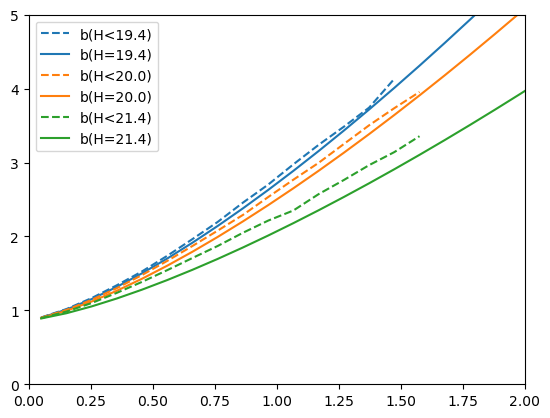

In [113]:
for k, i in enumerate([1, 4, 10]):
    plt.plot(config_survey_update['MagMax_redshift_centers'], config_survey_update['MagMax_mean_bias_redshift'][i], '--C'+str(k), label = f"b(H<{config_survey_update['MagMax_mag_centers'][i]:.1f})")
    plt.plot(config_survey_update['MagMax_redshift_centers'], bias_model.linear_bias(config_survey_update['MagMax_redshift_centers'], config_survey_update['MagMax_mag_centers'][i],tracer='MagMax'), '-C'+str(k), label = f"b(H={config_survey_update['MagMax_mag_centers'][i]:.1f})")

plt.xlim(0, 2)
plt.ylim(0, 5)
    #config_survey_update['MagMax_mean_bias_redshift'][i])
plt.legend()
    

In [114]:
for j in range(80):
    print(config_survey_update['MagMax_redshift_centers'][j], config_survey_update['MagMax_spec_redshift_density'][i][j], config_survey_update['MagMax_mean_bias_redshift'][i][j])


    

0.05084745762711865 662.3571428571429 0.895424599536889
0.15254237288135594 896.3035714285714 0.9834878732803587
0.2542372881355932 1233.3749999999998 1.0990366230762814
0.35593220338983056 2058.964285714286 1.2371109811734466
0.4576271186440678 1752.5357142857144 1.3858485376802097
0.5593220338983051 2029.5 1.5443494841697256
0.6610169491525424 2851.5535714285716 1.7088229315584462
0.7627118644067797 2887.5000000000005 1.8713513419754961
0.864406779661017 1911.6428571428573 2.0499035101248744
0.9661016949152542 1946.4107142857142 2.2142736787925514
1.0677966101694916 1195.6607142857144 2.351203858971415
1.1694915254237288 898.0714285714287 2.572505839612267
1.2711864406779663 719.5178571428571 2.7633603303412277
1.3728813559322035 609.9107142857142 2.9643644217839866
1.4745762711864407 589.2857142857143 3.14070289978818
1.5762711864406782 292.875 3.355972442167516
1.6779661016949152 0.0 nan
1.7796610169491527 0.0 nan
1.88135593220339 0.0 nan
1.9830508474576272 0.0 nan
2.08474576271186

IndexError: index 59 is out of bounds for axis 0 with size 59

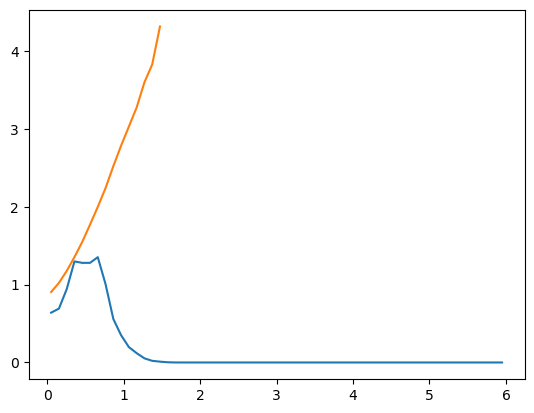

In [80]:
plt.plot(config_survey_update['MagMax_redshift_centers'],0.01*config_survey_update['MagMax_spec_redshift_density'][0])
plt.plot(config_survey_update['MagMax_redshift_centers'],config_survey_update['MagMax_mean_bias_redshift'][0])